Memuat model AI...
Sedang mendeteksi kepala pengunjung...

image 1/1 c:\Users\HS COMP\Desktop\QueueVision AI\notebooks\..\data\raw\frames\seq_000010.jpg: 480x640 32 persons, 158.0ms
Speed: 2.2ms preprocess, 158.0ms inference, 24.5ms postprocess per image at shape (1, 3, 480, 640)


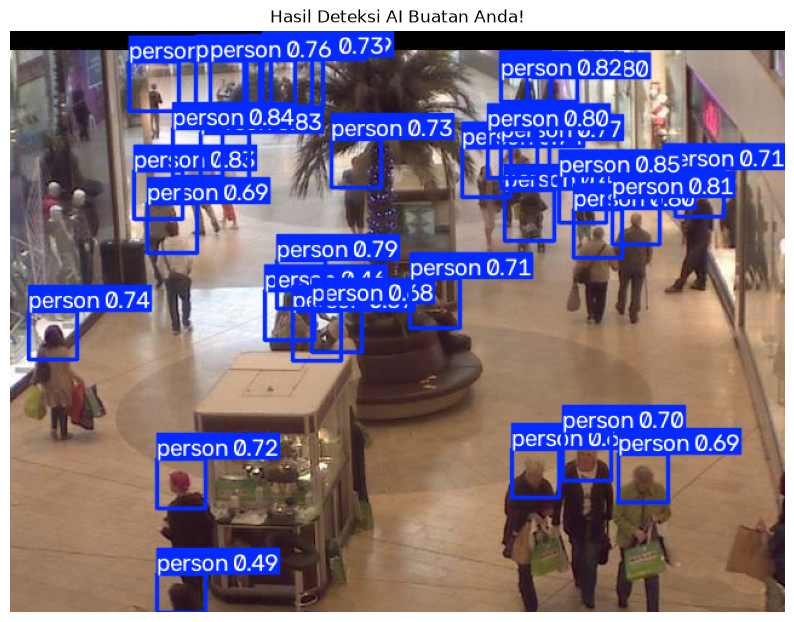

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Memuat model AI terbaik Anda
model_path = '../models/baseline/weights/best.pt'
print("Memuat model AI...")
model = YOLO(model_path)

# 2. Memilih satu gambar dari data validasi untuk dites
# Kita ambil salah satu gambar secara acak (pastikan gambar ini ada di folder Anda)
test_image = '../data/raw/frames/seq_000010.jpg' 

# 3. Menyuruh AI melakukan deteksi (prediksi)
print("Sedang mendeteksi kepala pengunjung...")
results = model(test_image, conf=0.25) # conf=0.25 artinya hanya menampilkan tebakan yang yakinnya di atas 25%

# 4. Menampilkan hasil kerja AI
# Mengambil gambar hasil gambaran AI
res_plotted = results[0].plot()

# Menampilkan di dalam notebook menggunakan matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("Hasil Deteksi AI Buatan Anda!")
plt.axis('off')
plt.show()

In [2]:
import cv2
import os
import glob

# 1. Menentukan lokasi folder gambar dan nama video output
# (Menggunakan folder dataset yang sudah Anda miliki)
image_folder = '../data/raw/frames' 
video_name = '../data/video_antrean.mp4'

print("Mencari file gambar...")
# 2. Mengambil semua gambar .jpg dan mengurutkannya sesuai nomor (sangat penting agar video lancar)
images = sorted(glob.glob(os.path.join(image_folder, '*.jpg')))

if not images:
    print("❌ Gambar tidak ditemukan. Coba cek kembali nama foldernya.")
else:
    # 3. Mengambil resolusi dari gambar pertama
    frame = cv2.imread(images[0])
    height, width, layers = frame.shape

    # 4. Mempersiapkan pembuat video (Codec MP4, kecepatan 15 Frame per Detik)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    video = cv2.VideoWriter(video_name, fourcc, 15, (width, height))

    print(f"Sedang menjahit {len(images)} gambar menjadi 1 video utuh. Mohon tunggu sebentar...")

    # 5. Memasukkan gambar satu per satu ke dalam video
    for image in images:
        video.write(cv2.imread(image))

    # 6. Menutup proses penyimpanan
    video.release()
    print(f"✅ Selesai! Video berhasil dibuat dan disimpan di: {video_name}")

Mencari file gambar...
Sedang menjahit 2000 gambar menjadi 1 video utuh. Mohon tunggu sebentar...
✅ Selesai! Video berhasil dibuat dan disimpan di: ../data/video_antrean.mp4


In [ ]:
from ultralytics import YOLO

# 1. Memanggil kembali AI terbaik kita
print("Membangunkan AI...")
model = YOLO('../models/baseline/weights/best.pt')

# 2. Menentukan lokasi video mentah yang baru saja kita buat
video_sumber = '../data/video_antrean.mp4'

print("AI sedang menonton dan menganalisis video... (Ini memakan waktu beberapa saat tergantung durasi video)")

# 3. Menyuruh AI menganalisis setiap frame di video dan menyimpan hasil videonya
# save=True artinya kita menyuruh AI menyimpan hasilnya menjadi file video baru
hasil = model.predict(
    source=video_sumber, 
    save=True,       # Simpan video hasil deteksi
    conf=0.25,       # Batas keyakinan minimal 25%
    project='../data',       # Simpan di folder data
    name='hasil_deteksi_ai'  # Nama sub-folder penyimpanannya
)

print("✅ Selesai! Video hasil deteksi AI berhasil disimpan.")